# CIFAR10

## nn.Sequential --> fonction

## nn.Dropout --> couche

In [79]:
import torch
import torchvision
import numpy as np
import matplotlib.pyplot as plt
torch.cuda.is_available()

False

In [80]:
from torchvision.transforms import ToTensor

dataset_train = torchvision.datasets.CIFAR10(
    root='./data_cifar_10',
    train= True,
    transform=ToTensor(),
    download=True,
)
dataset_test = torchvision.datasets.CIFAR10(
    root='./data_cifar_10',
    train= False,
    transform=ToTensor(),
    download=True,
)

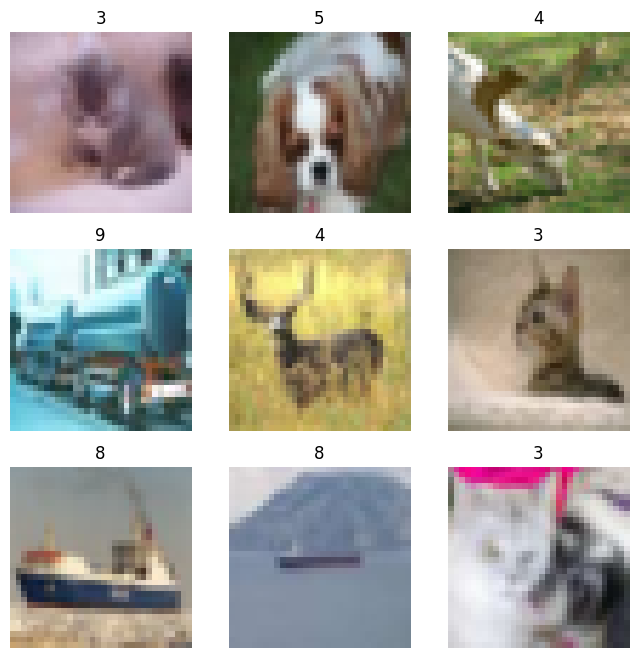

In [81]:
figure = plt.figure(figsize=(8,8))
cols, rows = 3, 3
for i in range(1, cols*rows+1):
    sample_idx = torch.randint(len(dataset_train), size=(1,)).item()
    img, label = dataset_train[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(label)
    plt.axis("off")
    plt.imshow(img.permute(1, 2, 0))
plt.show()

In [82]:
from torch.utils.data import DataLoader

dataloader_train = DataLoader(dataset_train, batch_size=64, shuffle=True)
dataloader_test = DataLoader(dataset_test, batch_size=64, shuffle=False)

In [83]:
train_features, train_labels = next(iter(dataloader_train))
train_features.size()

torch.Size([64, 3, 32, 32])

In [84]:
from torch import nn

def forward():
    model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(3*32*32, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, 10),
            nn.Softmax()
        )
    return model

In [85]:
mlp = forward()

print(mlp)

n_params = sum(p.numel() for p in mlp.parameters() if p.requires_grad)
print(f"\n[2.3] Paramètres entraînables : {n_params:,}")

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=3072, out_features=128, bias=True)
  (2): ReLU()
  (3): Dropout(p=0.5, inplace=False)
  (4): Linear(in_features=128, out_features=64, bias=True)
  (5): ReLU()
  (6): Dropout(p=0.5, inplace=False)
  (7): Linear(in_features=64, out_features=10, bias=True)
  (8): Softmax(dim=None)
)

[2.3] Paramètres entraînables : 402,250


In [86]:
x_dummy = torch.randn(1, 3072)
output = mlp(x_dummy)
print(f"\n[2.4] Forward pass : entrée {x_dummy.shape} --> {output.shape}")
print(f"Sortie : {output}")


[2.4] Forward pass : entrée torch.Size([1, 3072]) --> torch.Size([1, 10])
Sortie : tensor([[0.1039, 0.0850, 0.1006, 0.0877, 0.1298, 0.0807, 0.1196, 0.0905, 0.0990,
         0.1031]], grad_fn=<SoftmaxBackward0>)


/home/finex/Documents/IIM_A4/machine-learning-cours/.venv/lib/python3.14/site-packages/torch/nn/modules/module.py:1778: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


In [87]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(mlp.parameters(), lr=1e-3)

In [88]:
def train_loop(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()
    for batch, (X, y_true) in enumerate(dataloader):
        y_pred = model(X)
        loss = loss_fn(y_pred, y_true)

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if batch % 100 == 0:
            loss, current = loss.item(), batch * 64 + len(X)
            print(f"loss : {loss:>7f}   [{current:>5d} / {size:>5d}]")

def test_loop(dataloader, model, loss_fn):
    model.eval()
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss, correct = 0, 0

    with torch.no_grad():
        for X, y_true in dataloader:
            y_pred = model(X)
            test_loss += loss_fn(y_pred, y_true).item()
            correct += (y_pred.argmax(1) == y_true).type(torch.float).sum().item()
    
    test_loss /= num_batches
    correct /= size

    print(f"Test error : Accuracy : {(100 * correct):>0.1f}%, Avg loss : {test_loss:>8f}")

In [89]:
epochs = 5
for t in range(epochs):
    print("Epoch :", t+1)
    train_loop(dataloader_train, mlp, criterion, optimizer)
    test_loop(dataloader_test, mlp, criterion)

print("Done")

Epoch : 1
loss : 2.300735   [   64 / 50000]
loss : 2.288165   [ 6464 / 50000]
loss : 2.260326   [12864 / 50000]
loss : 2.249465   [19264 / 50000]
loss : 2.151287   [25664 / 50000]
loss : 2.175267   [32064 / 50000]
loss : 2.192649   [38464 / 50000]
loss : 2.258808   [44864 / 50000]
Test error : Accuracy : 28.4%, Avg loss : 2.173000
Epoch : 2
loss : 2.130267   [   64 / 50000]
loss : 2.194369   [ 6464 / 50000]
loss : 2.230954   [12864 / 50000]
loss : 2.227194   [19264 / 50000]
loss : 2.239514   [25664 / 50000]
loss : 2.221237   [32064 / 50000]
loss : 2.205277   [38464 / 50000]
loss : 2.215993   [44864 / 50000]
Test error : Accuracy : 31.2%, Avg loss : 2.143233
Epoch : 3
loss : 2.218218   [   64 / 50000]
loss : 2.186498   [ 6464 / 50000]
loss : 2.101870   [12864 / 50000]
loss : 2.165854   [19264 / 50000]
loss : 2.193477   [25664 / 50000]
loss : 2.242575   [32064 / 50000]
loss : 2.119805   [38464 / 50000]
loss : 2.163896   [44864 / 50000]
Test error : Accuracy : 32.8%, Avg loss : 2.125475
E